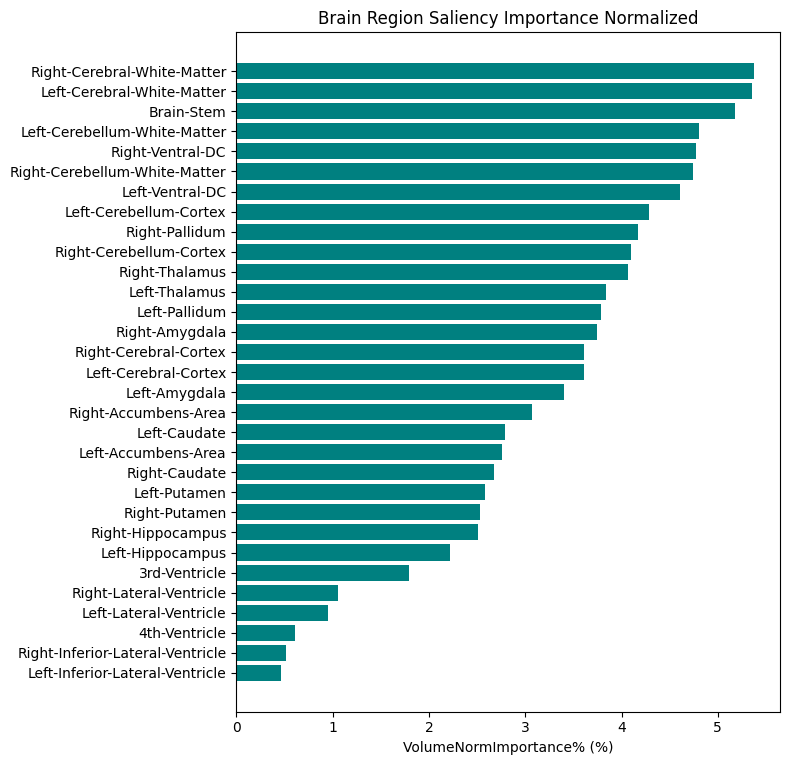

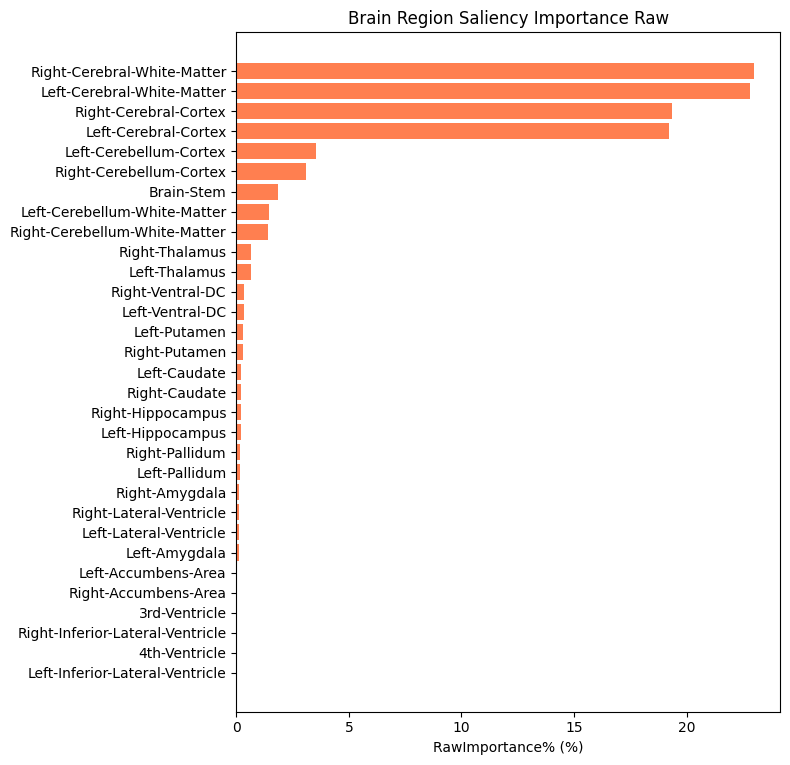

Saved plot to: ..\runs\ResNet18_best\sub-1017176_anatomical_importance_norm.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── CONFIG ──────────────────────────────────────────────
csv_path = r"..\runs\ResNet18_best\sub-1017176_anatomical_importance_norm.csv"
csv_path_raw = r"..\runs\ResNet18_best\sub-1017176_anatomical_importance_raw.csv"
output_dir = os.path.dirname(csv_path)
output_png = os.path.join(output_dir, "sub-1017176_anatomical_importance_norm.png")
output_png_raw = os.path.join(output_dir, "sub-1017176_anatomical_importance_raw.png")

# ── LOAD CSV ───────────────────────────────────────────
df = pd.read_csv(csv_path)
df_raw = pd.read_csv(csv_path_raw)

importance_col = df.columns[df.columns.str.contains("VolumeNormImportance%")][0]
importance_col_raw = df_raw.columns[df_raw.columns.str.contains("RawImportance%")][0]

df[importance_col] = df[importance_col] / df[importance_col].sum() * 100
df_raw[importance_col_raw] = df_raw[importance_col_raw] / df_raw[importance_col_raw].sum() * 100

# Drop rows with NaN importance
df_plot = df.dropna(subset=[importance_col]).sort_values(by=importance_col, ascending=True)
df_plot_raw = df_raw.dropna(subset=[importance_col_raw]).sort_values(by=importance_col_raw, ascending=True)

# ── PLOT ──────────────────────────────────────────────
plt.figure(figsize=(8, max(4, 0.25*len(df_plot))))
plt.barh(df_plot["Region"], df_plot[importance_col], color="teal")
plt.xlabel(f"{importance_col} (%)")
plt.title("Brain Region Saliency Importance Normalized")
plt.tight_layout()
plt.savefig(output_png, dpi=300)
plt.show()

plt.figure(figsize=(8, max(4, 0.25*len(df_plot_raw))))
plt.barh(df_plot_raw["Region"], df_plot_raw[importance_col_raw], color="coral")
plt.xlabel(f"{importance_col_raw} (%)")
plt.title("Brain Region Saliency Importance Raw")
plt.tight_layout()
plt.savefig(output_png_raw, dpi=300)
plt.show()

print(f"Saved plot to: {output_png}")

In [15]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import pyvista as pv
from skimage import measure

# ── CONFIG ──────────────────────────────────────────────
seg_path = r"C:\Users\janak\GitHub\ADHD-MRI-Deep-Learning\ADHD_BIDS\derivatives\labels\sub-1017176\1017176_desc-synthseg_dseg.nii.gz"
output_html = os.path.join(os.path.dirname(csv_path), "sub-1017176_brain_saliency.html")

# ── LOAD SEGMENTATION ──────────────────────────────────
seg_img = nib.load(seg_path)
seg_data = seg_img.get_fdata()
affine = seg_img.affine

# ── MAP CSV IMPORTANCE TO LABEL IDs ────────────────────
# 1. Your original ID-to-Name mapping
ID_TO_LABEL = {
    2: "Left-Cerebral-White-Matter", 3: "Left-Cerebral-Cortex", 4: "Left-Lateral-Ventricle", 
    5: "Left-Inferior-Lateral-Ventricle", 7: "Left-Cerebellum-White-Matter", 8: "Left-Cerebellum-Cortex",
    10: "Left-Thalamus", 11: "Left-Caudate", 12: "Left-Putamen", 13: "Left-Pallidum", 
    17: "Left-Hippocampus", 18: "Left-Amygdala", 26: "Left-Accumbens-Area", 28: "Left-Ventral-DC",
    41: "Right-Cerebral-White-Matter", 42: "Right-Cerebral-Cortex", 43: "Right-Lateral-Ventricle",
    44: "Right-Inferior-Lateral-Ventricle", 46: "Right-Cerebellum-White-Matter", 47: "Right-Cerebellum-Cortex",
    49: "Right-Thalamus", 50: "Right-Caudate", 51: "Right-Putamen", 52: "Right-Pallidum", 
    53: "Right-Hippocampus", 54: "Right-Amygdala", 58: "Right-Accumbens-Area", 60: "Right-Ventral-DC",
    14: "3rd-Ventricle", 15: "4th-Ventricle", 16: "Brain-Stem"
}

# 2. Create the reverse mapping (Name-to-ID)
# This loops through the items and swaps the key (k) and value (v)
LABEL_TO_ID = {v: k for k, v in ID_TO_LABEL.items()}

# Create an empty 3D volume for importance values
importance_map = np.zeros_like(seg_data, dtype=np.float32)

for _, row in df.iterrows():
    region_name = row["Region"]
    value = row[importance_col]
    label_id = LABEL_TO_ID.get(region_name)
    if label_id is not None:
        importance_map[seg_data == label_id] = value

# Normalize importance to 0-1
importance_map_norm = importance_map / np.max(importance_map)

# ── EXTRACT SURFACES USING MARCHING CUBES ─────────────
# Only extract regions with non-zero importance
verts, faces, normals, values = measure.marching_cubes(
    volume=importance_map_norm, level=0.001
)
faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32)

# ── CREATE PYVISTA MESH ───────────────────────────────
mesh = pv.PolyData(verts, faces)
mesh["Importance"] = values

# ── PLOT INTERACTIVE 3D BRAIN ────────────────────────
plotter = pv.Plotter()
plotter.add_mesh(mesh, scalars="Importance", cmap="hot", show_edges=False)
plotter.add_scalar_bar(title="Importance", n_labels=5)
plotter.add_axes()
plotter.show_grid()

# Export to interactive HTML
plotter.export_html(output_html)
print(f"Saved interactive 3D brain visualization to: {output_html}")

Saved interactive 3D brain visualization to: ..\runs\ResNet18_best\sub-1017176_brain_saliency.html


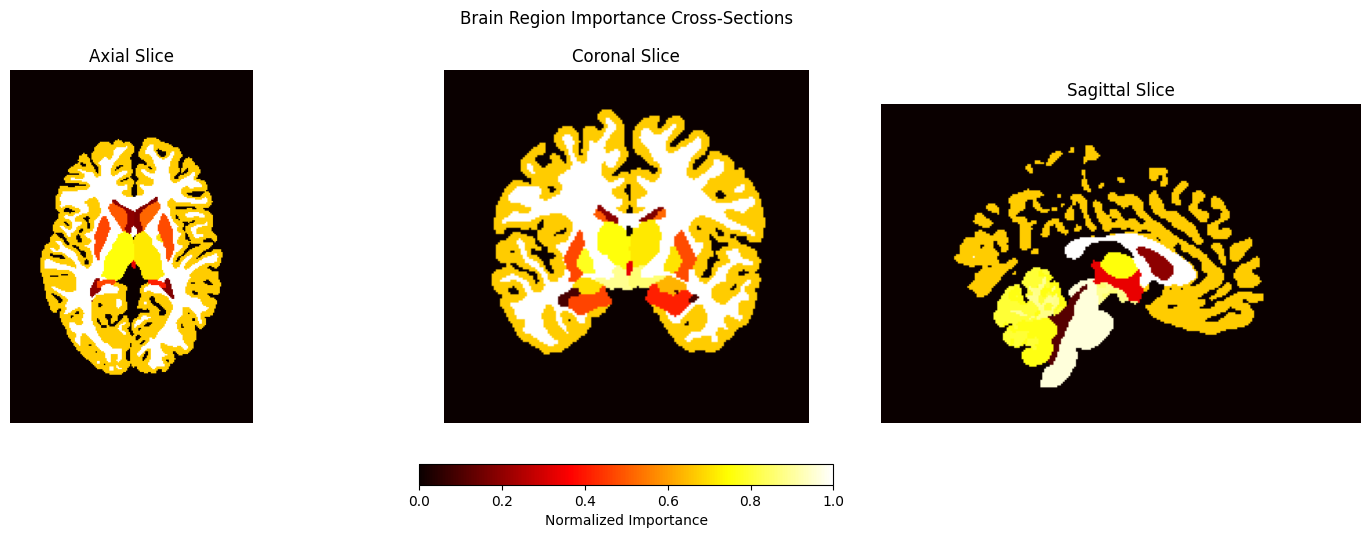

In [16]:
import matplotlib.pyplot as plt

# ── CREATE CROSS-SECTIONAL VIEWS WITH SCALE ──────────
center = np.array(importance_map_norm.shape) // 2

# ── CROSS-SECTIONAL VIEWS WITH HORIZONTAL COLORBAR ─────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial (top-down)
im0 = axes[0].imshow(importance_map_norm[:, :, center[2]].T, origin='lower', cmap='hot')
axes[0].set_title("Axial Slice")

# Coronal (front view)
im1 = axes[1].imshow(importance_map_norm[:, center[1], :].T, origin='lower', cmap='hot')
axes[1].set_title("Coronal Slice")

# Sagittal (side view)
im2 = axes[2].imshow(importance_map_norm[center[0], :, :].T, origin='lower', cmap='hot')
axes[2].set_title("Sagittal Slice")

for ax in axes:
    ax.axis('off')

plt.suptitle("Brain Region Importance Cross-Sections")
plt.tight_layout()

# Add a single horizontal colorbar below the subplots
cbar = fig.colorbar(im0, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label("Normalized Importance")

plt.savefig(os.path.join(output_dir, "sub-1017176_brain_saliency_cross_sections.png"), dpi=300, bbox_inches='tight')

plt.show()